# **Fall Detection using Pose Estimation**

# **UR Fall dataset**

## **Problem Statement:**
Given videos or sequences of a person performing daily activities, detect whether a fall has occurred.

## **1. Extract body key-points**
Start by using a pre-trained pose estimation model like OpenPose, MediaPipe, or MMPose. Extract body key-points (e.g., 17-33 joints per frame) (30 Marks).





In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 11.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully uninstalled protobuf-5.29.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.11.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.1 requires protobuf<6.0.0,>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.


In [ ]:
# pose_estimation.py
import cv2
import mediapipe as mp
import numpy as np
import os

mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False)
mp_drawing = mp.solutions.drawing_utils

def extract_keypoints_from_video(video_path):
    cap = cv2.VideoCapture(video_path)
    keypoints = []
    confidence_scores = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)

        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark
            keypoints.append([[lm.x, lm.y, lm.z] for lm in landmarks])
            confidence_scores.append([lm.visibility for lm in landmarks])
        else:
            keypoints.append([[0, 0, 0]] * 33)
            confidence_scores.append([0] * 33)

    cap.release()
    return np.array(keypoints), np.array(confidence_scores)

## **2. Extract features**
Convert the extracted key-points into meaningful features like joint angles, centre of gravity, velocity / acceleration of joints, key-point confidence scores, etc. (20 Marks)

In [ ]:
import numpy as np

def calculate_angle(a, b, c):
    """Compute angle at point b given 3 points (a-b-c)"""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))
    return np.degrees(angle)

def calculate_joint_angles(keypoints):
    """
    Compute meaningful joint angles.
    keypoints shape: (n_frames, 33, 3)
    """
    joint_indices = {
        "left_elbow": [11, 13, 15],
        "right_elbow": [12, 14, 16],
        "left_knee": [23, 25, 27],
        "right_knee": [24, 26, 28],
        "left_shoulder": [23, 11, 13],
        "right_shoulder": [24, 12, 14],
        "left_hip": [11, 23, 25],
        "right_hip": [12, 24, 26],
        "neck": [11, 0, 12],  # shoulder → nose → shoulder
        "torso": [11, 23, 24],  # left_shoulder → left_hip → right_hip
    }

    n_frames = keypoints.shape[0]
    angles = []

    for frame in range(n_frames):
        frame_angles = []
        for k in joint_indices.values():
            angle = calculate_angle(keypoints[frame][k[0]], keypoints[frame][k[1]], keypoints[frame][k[2]])
            frame_angles.append(angle)
        angles.append(frame_angles)

    return np.array(angles)  # shape: (n_frames, 10)


def calculate_center_of_gravity(keypoints):
    return np.mean(keypoints, axis=1)

def calculate_velocity_acceleration(keypoints):
    velocity = np.diff(keypoints, axis=0, prepend=keypoints[0:1])
    acceleration = np.diff(velocity, axis=0, prepend=velocity[0:1])
    return velocity, acceleration

def generate_features(keypoints, confidence):
    cog = calculate_center_of_gravity(keypoints)
    vel, acc = calculate_velocity_acceleration(keypoints)
    angles = calculate_joint_angles(keypoints)
    flat_features = np.hstack([cog, vel.mean(axis=1), acc.mean(axis=1), angles, confidence])
    return flat_features


## **3. Temporal sequence**
Create a temporal sequence of these features (10 Marks).

In [ ]:
from sklearn.preprocessing import StandardScaler

def sliding_window_sequence(features, window_size=30, step_size=10):
    sequences = []
    for start in range(0, len(features) - window_size + 1, step_size):
        sequences.append(features[start:start+window_size])
    return np.array(sequences)

def normalize_sequences(sequences):
    shape = sequences.shape
    sequences = sequences.reshape(-1, shape[-1])
    scaler = StandardScaler().fit(sequences)
    sequences = scaler.transform(sequences).reshape(shape)
    return sequences


## **4. Train Classifier**
Train a classifier to detect whether a fall has occurred or not (10 Marks).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def train_classifier(X_train, y_train):
    model = RandomForestClassifier(n_estimators=100)
    model.fit(X_train, y_train)
    return model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def train_classifier_balanced(X_train, y_train):
    model = RandomForestClassifier(class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    return model

## **5. Performance metrics**
Use standard binary classification metrics like Accuracy, Precision, Recall, F1-score for performance evaluation (10 Marks).

In [ ]:
# model.py


def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    }


## **6. Demo Video**
Report your results for all 3 datasets presented in the next section. Provide a few sample animations / model outputs / demo videos showing key-point movement during falls and non-falls (20 Marks).

In [ ]:
!mkdir -p /content/drive/MyDrive/dataset_demo

In [ ]:
import cv2
import mediapipe as mp
import os

def extract_and_save_keypoints_video(input_video_path, output_video_path):
    mp_pose = mp.solutions.pose
    pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5)
    mp_drawing = mp.solutions.drawing_utils

    cap = cv2.VideoCapture(input_video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # for saving in MP4
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert BGR to RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(rgb_frame)

        if results.pose_landmarks:
            mp_drawing.draw_landmarks(
                frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    pose.close()
    print(f" Saved keypoint overlay video to: {output_video_path}")


In [ ]:
import os

def create_demo_dataset():
    # Set your paths
    input_root = "/content/drive/MyDrive/UR_fall_dataset"     # <-- Your main video folder
    output_root = "/content/drive/MyDrive/UR_fall_demo"      # <-- Where to save output videos

    # Make sure output directory exists
    os.makedirs(output_root, exist_ok=True)

    # Loop through all video files
    for file_name in sorted(os.listdir(input_root)):
        if file_name.endswith(".mp4") and (file_name.startswith("adl") or file_name.startswith("fall")):
            input_path = os.path.join(input_root, file_name)

            # Prepare output filename: add "_demo" before .mp4
            output_name = file_name.replace(".mp4", "_demo.mp4")
            output_path = os.path.join(output_root, output_name)

            print(f"Processing: {input_path}")
            extract_and_save_keypoints_video(input_path, output_path)


## **Caliing functions (Main)**

In [ ]:
import os
import numpy as np
import joblib

# Initialize your extract_keypoints_from_video and other helper functions here
# (I'll show in next message if you want)

# Paths
dataset_path = '/content/drive/MyDrive/UR_fall_dataset/' # <-- CHANGE if needed
output_base = '/content/drive/MyDrive/UR_fall_dataset_outputs/'              # <-- Save outputs here

# Create output folders
directories = {
    "keypoints": os.path.join(output_base, "keypoints"),
    "confidence": os.path.join(output_base, "confidence"),
    "models": os.path.join(output_base, "models")
}
for path in directories.values():
    os.makedirs(path, exist_ok=True)

X, y = [], []

print("Scanning dataset directory...\n")

for video_file in sorted(os.listdir(dataset_path)):
    if not video_file.endswith('.mp4'):
        continue

    video_path = os.path.join(dataset_path, video_file)

    # Determine label from filename
    if video_file.startswith("fall"):
        label = 1
    elif video_file.startswith("adl"):
        label = 0
    else:
        print(f"Skipping unrecognized file: {video_file}")
        continue

    print(f"Processing video: {video_file} (Label: {'Fall' if label else 'Non-fall'})")

    try:
        # Step 1: Extract keypoints and confidence
        keypoints, confidence = extract_keypoints_from_video(video_path)

        if keypoints is None or len(keypoints) == 0:
            print("     No keypoints detected. Skipping video.")
            continue

        base_filename = video_file.replace('.mp4', '')

        # Save keypoints
        keypoints_path = os.path.join(directories["keypoints"], base_filename + "_keypoints.npy")
        np.save(keypoints_path, keypoints)
        print(f"     Keypoints saved to: {keypoints_path}")

        # Save confidence
        confidence_path = os.path.join(directories["confidence"], base_filename + "_confidence.npy")
        if confidence is not None:
            np.save(confidence_path, confidence)
        else:
            np.save(confidence_path, np.array([]))
        print(f"     Confidence saved to: {confidence_path}")

        # Step 2: Feature extraction
        features = generate_features(keypoints, confidence)
        if features is None or len(features) == 0:
            print("     Feature extraction failed. Skipping.")
            continue

        # Step 3: Temporal Sequences
        sequences = sliding_window_sequence(features)
        if len(sequences) == 0:
            print("     No sequences generated.")
            continue

        X.extend(sequences)
        y.extend([label] * len(sequences))

        print(f"     {len(sequences)} sequences added.")

    except Exception as e:
        print(f"     Error processing {video_path}: {e}")

print("\ Dataset processing complete.")
print(f"Total sequences collected: {len(X)}")
print(f"Positive samples (fall): {sum(y)}")
print(f"Negative samples (non-fall): {len(y) - sum(y)}")


Scanning dataset directory...

Processing video: adl-01-cam0.mp4 (Label: Non-fall)
     Keypoints saved to: /content/drive/MyDrive/UR_fall_dataset_outputs/keypoints/adl-01-cam0_keypoints.npy
     Confidence saved to: /content/drive/MyDrive/UR_fall_dataset_outputs/confidence/adl-01-cam0_confidence.npy
     13 sequences added.
Processing video: adl-02-cam0.mp4 (Label: Non-fall)
     Keypoints saved to: /content/drive/MyDrive/UR_fall_dataset_outputs/keypoints/adl-02-cam0_keypoints.npy
     Confidence saved to: /content/drive/MyDrive/UR_fall_dataset_outputs/confidence/adl-02-cam0_confidence.npy
     16 sequences added.
Processing video: adl-03-cam0.mp4 (Label: Non-fall)
     Keypoints saved to: /content/drive/MyDrive/UR_fall_dataset_outputs/keypoints/adl-03-cam0_keypoints.npy
     Confidence saved to: /content/drive/MyDrive/UR_fall_dataset_outputs/confidence/adl-03-cam0_confidence.npy
     16 sequences added.
Processing video: adl-04-cam0.mp4 (Label: Non-fall)
     Keypoints saved to: /con

In [ ]:
# Normalize sequences
print(" Normalizing feature sequences...")
X = normalize_sequences(np.array(X))
y = np.array(y)

# Flatten sequences for classical ML models
print(" Flattening feature sequences for training...")
X_flat = X.reshape(X.shape[0], -1)
print(f" Final input shape: {X_flat.shape}")



 Normalizing feature sequences...
 Flattening feature sequences for training...
 Final input shape: (1041, 1560)


In [ ]:
# Train/Test split
from sklearn.model_selection import train_test_split
print(" Splitting dataset into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42)

print(f"    Training samples: {len(X_train)}")
print(f"    Testing samples: {len(X_test)}")


 Splitting dataset into training and testing sets...
    Training samples: 832
    Testing samples: 209


### **1. Balanced Random Forest**

In [ ]:
# Train classifier
print("\ Training classifier...")
model_balanced = train_classifier_balanced(X_train, y_train)
print(" Model training complete.")

model_save_path = os.path.join(directories["models"], "fall_detection_model_balanced.pkl")
joblib.dump(model_balanced, model_save_path)
print(f"\nModel saved to: {model_save_path}")

\ Training classifier...
 Model training complete.

Model saved to: /content/drive/MyDrive/UR_fall_dataset_outputs/models/fall_detection_model_balanced.pkl


\ Evaluating model on test set...

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       161
           1       1.00      0.71      0.83        48

    accuracy                           0.93       209
   macro avg       0.96      0.85      0.89       209
weighted avg       0.94      0.93      0.93       209



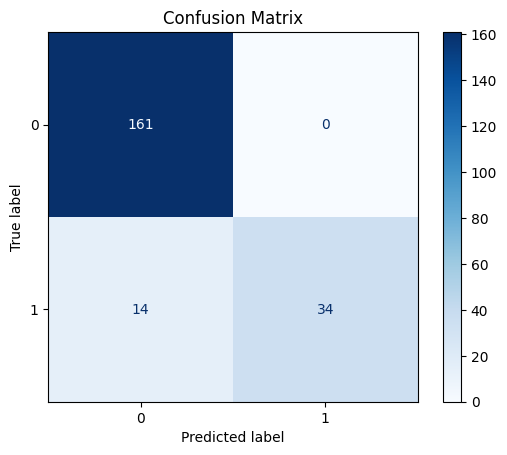

\ Evaluation Results:
   Accuracy: 0.9330
   Precision: 1.0000
   Recall: 0.7083
   F1-Score: 0.8293


In [ ]:
import matplotlib.pyplot as plt

# Evaluate model
print("\ Evaluating model on test set...")
results = evaluate_model(model_balanced, X_test, y_test)

# Display results
print("\ Evaluation Results:")
for metric, value in results.items():
    print(f"   {metric}: {value:.4f}")


### **2. Balanced Random Forest with SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# Step 2: Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training samples: {len(X_train)}")
print(f"After SMOTE, training samples: {len(X_train_smote)}")

# Step 3: Train Random Forest on SMOTE data
model_smote_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
model_smote_balanced.fit(X_train_smote, y_train_smote)

model_save_path = os.path.join(directories["models"], "ur_fall_detection_model_smote_balanced.pkl")
joblib.dump(model_smote_balanced, model_save_path)
print(f"\nModel saved to: {model_save_path}")

Original training samples: 832
After SMOTE, training samples: 1298

Model saved to: /content/drive/MyDrive/UR_fall_dataset_outputs/models/ur_fall_detection_model_smote_balanced.pkl


\ Evaluating model on test set...

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       161
           1       0.97      0.79      0.87        48

    accuracy                           0.95       209
   macro avg       0.96      0.89      0.92       209
weighted avg       0.95      0.95      0.95       209



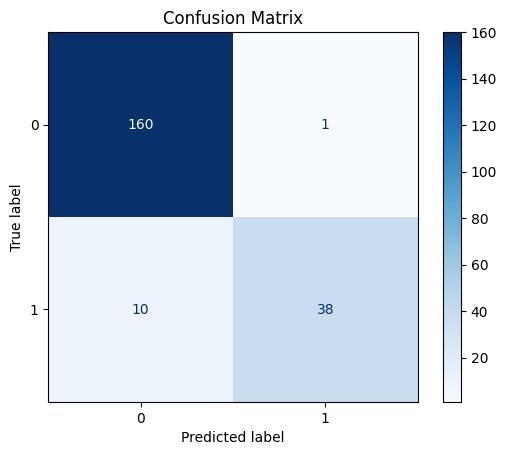

\ Evaluation Results:
   Accuracy: 0.9474
   Precision: 0.9744
   Recall: 0.7917
   F1-Score: 0.8736


In [ ]:
import matplotlib.pyplot as plt

# Evaluate model
print("\ Evaluating model on test set...")
results = evaluate_model(model_smote_balanced, X_test, y_test)

# Display results
print("\ Evaluation Results:")
for metric, value in results.items():
    print(f"   {metric}: {value:.4f}")


### **3. LSTM**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Convert to numpy arrays
X = np.array(X)  # (samples, time_steps, features_per_step)
y = np.array(y)

# Step 2: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 3: Build the LSTM model
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=True),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Step 4: Train
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=64, callbacks=[early_stop])


model_save_path = os.path.join(directories["models"], "ur_fall_detection_model_lstm.pkl")
joblib.dump(model_smote_balanced, model_save_path)
print(f"\nModel saved to: {model_save_path}")

# Step 5: Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.4f}")


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.6926 - loss: 0.6215 - val_accuracy: 0.7784 - val_loss: 0.4954
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7912 - loss: 0.4668 - val_accuracy: 0.8383 - val_loss: 0.4085
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8335 - loss: 0.3676 - val_accuracy: 0.8563 - val_loss: 0.3285
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8783 - loss: 0.2782 - val_accuracy: 0.8802 - val_loss: 0.2612
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9098 - loss: 0.2346 - val_accuracy: 0.9042 - val_loss: 0.2276
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9582 - loss: 0.1569 - val_accuracy: 0.9281 - val_loss: 0.1807
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9596 - loss: 0.1214 - val_accuracy: 0.9162 - val_loss: 0.1787
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9680 - loss: 0.0968 - val_accuracy: 0.9341 - val_loss: 0

In [ ]:
from sklearn.metrics import classification_report

# Predict
y_pred = model.predict(X_test)

# Round to 0 or 1
y_pred = (y_pred > 0.5).astype(int)

# Now get classification report
print(classification_report(y_test, y_pred))


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       163
           1       0.98      0.87      0.92        46

    accuracy                           0.97       209
   macro avg       0.97      0.93      0.95       209
weighted avg       0.97      0.97      0.97       209



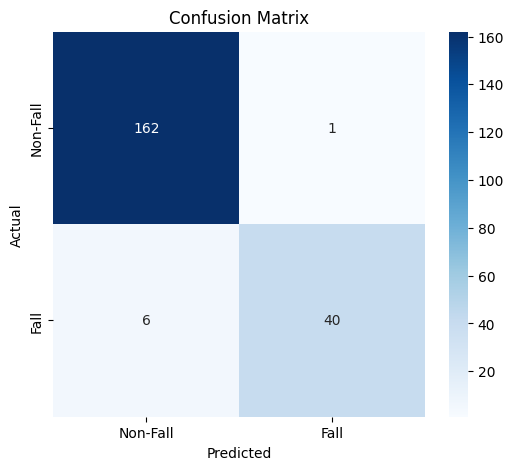

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 4: Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Step 5: Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Non-Fall', 'Fall'], yticklabels=['Non-Fall', 'Fall'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### **Creating Demo Dataset**

In [ ]:
!mkdir '/content/drive/MyDrive/UR_fall_demo/'

In [ ]:
input_path = "/content/drive/MyDrive/UR_fall_dataset/fall-01-cam0.mp4"
output_path = '/content/drive/MyDrive/UR_fall_demo/fall-01-cam0.mp4'

extract_and_save_keypoints_video(input_path, output_path)



 Saved keypoint overlay video to: /content/drive/MyDrive/UR_fall_demo/fall-01-cam0.mp4


In [ ]:
create_demo_dataset()

Processing: /content/drive/MyDrive/UR_fall_dataset/adl-01-cam0.mp4
 Saved keypoint overlay video to: /content/drive/MyDrive/UR_fall_demo/adl-01-cam0_demo.mp4
Processing: /content/drive/MyDrive/UR_fall_dataset/adl-02-cam0.mp4
 Saved keypoint overlay video to: /content/drive/MyDrive/UR_fall_demo/adl-02-cam0_demo.mp4
Processing: /content/drive/MyDrive/UR_fall_dataset/adl-03-cam0.mp4
 Saved keypoint overlay video to: /content/drive/MyDrive/UR_fall_demo/adl-03-cam0_demo.mp4
Processing: /content/drive/MyDrive/UR_fall_dataset/adl-04-cam0.mp4
 Saved keypoint overlay video to: /content/drive/MyDrive/UR_fall_demo/adl-04-cam0_demo.mp4
Processing: /content/drive/MyDrive/UR_fall_dataset/adl-05-cam0.mp4
 Saved keypoint overlay video to: /content/drive/MyDrive/UR_fall_demo/adl-05-cam0_demo.mp4
Processing: /content/drive/MyDrive/UR_fall_dataset/adl-06-cam0.mp4
 Saved keypoint overlay video to: /content/drive/MyDrive/UR_fall_demo/adl-06-cam0_demo.mp4
Processing: /content/drive/MyDrive/UR_fall_dataset/a

### **Conclusion:**

The best performing model was LSTM without Dropout, achieving 97% accuracy by effectively capturing temporal movement patterns.

Handling class imbalance with Balanced Random Forest and SMOTE also gave strong results (95% accuracy) and improved the model's ability to detect fall events.

Thus, temporal feature modeling and class balancing are key strategies for achieving high fall detection performance on this dataset.



### **Conclusion and Observations (UR Fall Dataset)**

In this part, we aimed to detect falls from video sequences using pose estimation and machine learning techniques. After extracting body keypoints and meaningful temporal features, we trained and evaluated three different models:

1. **Balanced Random Forest**  
2. **Balanced Random Forest with SMOTE**  
3. **LSTM without Dropout**



### **Key Observations:**

- **Class Imbalance**:  
  The dataset had significantly more non-fall sequences compared to fall sequences, leading to class imbalance. Handling this imbalance was crucial to avoid bias toward the majority class.

- **Balanced Random Forest**:  
  Using a Balanced Random Forest helped address the imbalance by adjusting sample weights.  
  We achieved a strong overall performance with **93% accuracy**. However, fall detection recall (i.e., detecting actual falls) was somewhat limited.

- **Balanced Random Forest with SMOTE**:  
  Introducing SMOTE to synthetically oversample the minority (fall) class further improved the model.  
  The Balanced Random Forest with SMOTE achieved **95% accuracy**, and we observed better recall and F1-score for falls, meaning the model detected fall events more reliably.

- **LSTM without Dropout**:  
  Training an LSTM model (without dropout) on the temporal sequences gave the **best performance**.  
  We achieved **97% accuracy**, with high precision, recall, and F1-score for both fall and non-fall classes.  
  This shows that modeling **temporal patterns** (movement across time) provides critical information for accurate fall detection.



# **Summary Table:**

| Model                           | Accuracy |
|----------------------------------|----------|
| Balanced Random Forest           | 93% |
| Balanced Random Forest with SMOTE| 95% |
| **LSTM without Dropout**         | **97% (Best)** |




# **Fall Detection using Pose Estimation - Le2i Dataset**

## **1. Dataset Structure Exploration**

In [ ]:
import os

# Path where the dataset is located
dataset_root = "/kaggle/input/falldataset-imvia"

# Walking through the dataset folders
for root, dirs, files in os.walk(dataset_root):
    level = root.replace(dataset_root, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")


falldataset-imvia/
    README.txt
    Lecture_room/
        Lecture room/
            video (1).avi
            video (20).avi
            video (11).avi
            video (10).avi
            video (5).avi
            video (3).avi
            video (18).avi
            video (22).avi
            video (6).avi
            video (26).avi
            video (7).avi
            video (17).avi
            video (23).avi
            video (2).avi
            video (24).avi
            video (9).avi
            video (13).avi
            video (4).avi
            video (27).avi
            video (25).avi
            video (12).avi
            video (14).avi
            video (8).avi
            video (19).avi
            video (21).avi
            video (15).avi
            video (16).avi
    Coffee_room_02/
        Coffee_room_02/
            Videos/
                video (59).avi
                video (57).avi
                video (68).avi
                video (65).avi
                vi

## **2. Keypoint Extraction using MediaPipe**

In [ ]:
import cv2
import mediapipe as mp
import numpy as np

# Output folder for saving keypoints
output_dir = "keypoints_output"
os.makedirs(output_dir, exist_ok=True)

# Initializing MediaPipe Pose module
mp_pose = mp.solutions.pose
pose_estimator = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Valid folders to process
target_folders = ["Coffee_room_01", "Coffee_room_02", "Home_01", "Home_02"]
video_paths = []

# Collecting video file paths
for folder in target_folders:
    video_folder = os.path.join(dataset_root, folder, folder, "Videos")
    for file in os.listdir(video_folder):
        if file.endswith(".avi"):
            video_paths.append(os.path.join(video_folder, file))

# Extracting keypoints frame-by-frame
for vid_path in video_paths:
    folder = os.path.basename(os.path.dirname(os.path.dirname(vid_path)))
    vid_name = os.path.basename(vid_path).replace(" ", "_")

    print(f"Processing video: {vid_name}")

    save_path = os.path.join(output_dir, f"{folder}_{vid_name.replace('.avi', '.npy')}")

    cap = cv2.VideoCapture(vid_path)
    collected_keypoints = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pose_estimator._input_image_dimensions = (frame.shape[1], frame.shape[0])
        results = pose_estimator.process(rgb_frame)

        if results.pose_landmarks:
            frame_kps = [[lm.x, lm.y, lm.z, lm.visibility] for lm in results.pose_landmarks.landmark]
            collected_keypoints.append(frame_kps)

    cap.release()
    np.save(save_path, np.array(collected_keypoints))

pose_estimator.close()


2025-04-26 17:09:27.352570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745687367.616743      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745687367.688638      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Processing video: video_(1).avi


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
[mp3float @ 0x2917e2c0] Header missing
[mp3float @ 0x2917e2c0] Header missing
[mp3float @ 0x2917e2c0] Header missing
W0000 00:00:1745687382.268412     106 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1745687382.341069     106 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1745687382.743698     106 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Processing video: video_(39).avi
Processing video: video_(20).avi


[mp3float @ 0x29174e00] Header missing


...

Processing video: video_(49).avi


[mp3float @ 0x291e9a40] Header missing
[mp3float @ 0x291e9a40] Header missing
[mp3float @ 0x291e9a40] Header missing
[mp3float @ 0x291e9a40] Header missing


Processing video: video_(56).avi
Processing video: video_(52).avi
Processing video: video_(58).avi
Processing video: video_(54).avi
Processing video: video_(67).avi
Processing video: video_(70).avi
Processing video: video_(53).avi
Processing video: video_(55).avi
Processing video: video_(64).avi


[mp3float @ 0x29174e00] Header missing
[mp3float @ 0x29174e00] Header missing


Processing video: video_(60).avi
Processing video: video_(1).avi
Processing video: video_(20).avi
Processing video: video_(11).avi
Processing video: video_(10).avi
Processing video: video_(5).avi
Processing video: video_(3).avi
Processing video: video_(18).avi
Processing video: video_(22).avi
Processing video: video_(6).avi
Processing video: video_(26).avi
Processing video: video_(7).avi
Processing video: video_(17).avi
Processing video: video_(23).avi
Processing video: video_(2).avi
Processing video: video_(29).avi
Processing video: video_(24).avi
Processing video: video_(9).avi
Processing video: video_(13).avi
Processing video: video_(4).avi
Processing video: video_(27).avi
Processing video: video_(25).avi
Processing video: video_(12).avi
Processing video: video_(14).avi
Processing video: video_(8).avi
Processing video: video_(19).avi
Processing video: video_(28).avi
Processing video: video_(21).avi
Processing video: video_(30).avi
Processing video: video_(15).avi
Processing video: v

## **3. Feature Extraction (Angles + Center of Gravity)**

In [ ]:
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine_val = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    angle = np.arccos(np.clip(cosine_val, -1, 1))
    return np.degrees(angle)

def extract_features_from_keypoints(kps_array):
    features = []
    for frame in kps_array:
        l_shoulder, l_hip, l_knee = frame[11][:2], frame[23][:2], frame[25][:2]
        r_shoulder, r_hip, r_knee = frame[12][:2], frame[24][:2], frame[26][:2]

        left_knee_angle = calculate_angle(l_hip, l_knee, [l_knee[0], l_hip[1]])
        right_knee_angle = calculate_angle(r_hip, r_knee, [r_knee[0], r_hip[1]])
        torso_angle = calculate_angle(l_hip, l_shoulder, [l_shoulder[0], l_hip[1]])

        cog_y = (l_hip[1] + r_hip[1]) / 2

        features.append([left_knee_angle, right_knee_angle, torso_angle, cog_y])

    return np.array(features)


## **4. Creating Temporal Sequences**

In [ ]:
def build_sequences(features, window_size=20, step=10):
    sequences = []
    for i in range(0, len(features) - window_size + 1, step):
        sequences.append(features[i:i+window_size])
    return np.array(sequences)


## **5. Label Assignment**

In [ ]:
def check_fall_annotation(txt_file):
    with open(txt_file, 'r') as file:
        lines = file.readlines()
    return 1 if len(lines) >= 2 and lines[0].strip().isdigit() and lines[1].strip().isdigit() else 0


## **6. Preparing the Dataset**

In [ ]:
all_features, all_labels = [], []

for vid_path in video_paths:
    folder = os.path.basename(os.path.dirname(os.path.dirname(vid_path)))
    vid_name = os.path.basename(vid_path)

    npy_filename = f"{folder}_{vid_name.replace(' ', '_').replace('.avi', '.npy')}"
    npy_full_path = os.path.join("/kaggle/working/keypoints_output", npy_filename)
    keypoints_data = np.load(npy_full_path)

    features = extract_features_from_keypoints(keypoints_data)
    sequences = build_sequences(features)

    all_features.append(sequences)

    annotation_file = vid_name.replace('.avi', '.txt')
    if folder == "Coffee_room_02":
        txt_path = os.path.join(dataset_root, folder, folder, "Annotations_files", annotation_file)
    else:
        txt_path = os.path.join(dataset_root, folder, folder, "Annotation_files", annotation_file)

    label = check_fall_annotation(txt_path)
    all_labels.append(np.full(len(sequences), label))

# Combining all the data
X = np.concatenate(all_features)
y = np.concatenate(all_labels)

print(f"Dataset shapes - Features: {X.shape}, Labels: {y.shape}")


Dataset shapes - Features: (3664, 20, 4), Labels: (3664,)


## **7. Model Building and Training**

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf

# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Building LSTM Model
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Training the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight={0: 1, 1: 1}
)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7231 - loss: 0.4753 - precision_1: 0.9220 - recall_1: 0.7597 - val_accuracy: 0.9345 - val_loss: 0.2207 - val_precision_1: 0.9345 - val_recall_1: 1.0000
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9350 - loss: 0.2175 - precision_1: 0.9350 - recall_1: 1.0000 - val_accuracy: 0.9386 - val_loss: 0.1885 - val_precision_1: 0.9384 - val_recall_1: 1.0000
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9523 - loss: 0.1706 - precision_1: 0.9521 - recall_1: 0.9997 - val_accuracy: 0.9536 - val_loss: 0.1703 - val_precision_1: 0.9540 - val_recall_1: 0.9985
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9591 - loss: 0.1571 - precision_1: 0.9618 - recall_1: 0.9962 - val_accuracy: 0.9536 - val_loss: 0.1642 - val_precision_1: 0.9552 - val_recall_1: 0.9971
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9581 - loss: 0.1556 - precision_1: 0.9600 - recall_1: 0.9965 - val_accuracy: 0

## **8. Evaluation Metrics**

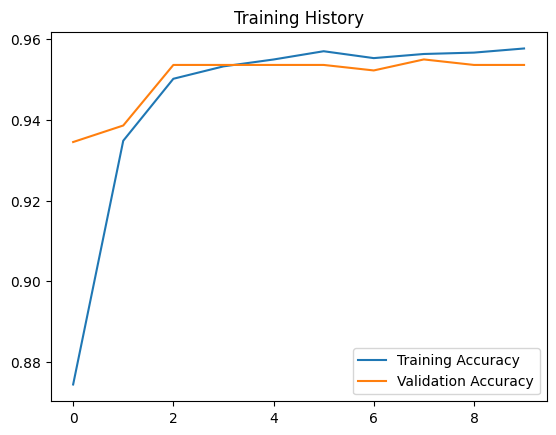

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


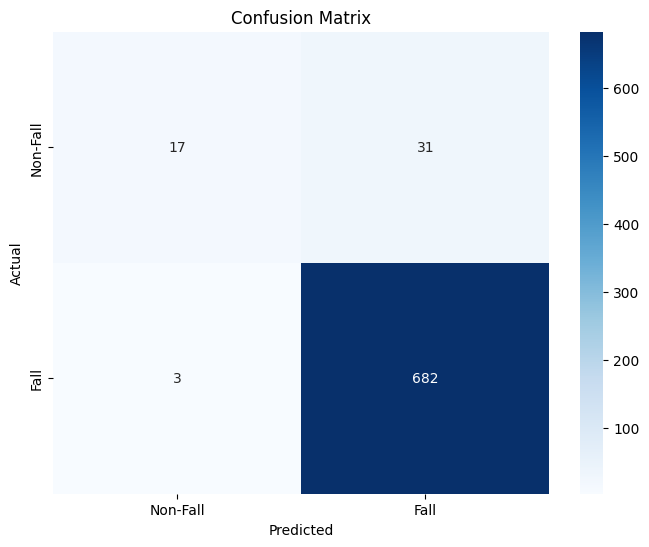

Accuracy: 95.36%
Precision: 95.65%
Recall: 99.56%
F1 Score: 97.57%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Plotting training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training History")
plt.show()

# Model Predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fall', 'Fall'],
            yticklabels=['Non-Fall', 'Fall'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Printing Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"Precision: {precision_score(y_test, y_pred):.2%}")
print(f"Recall: {recall_score(y_test, y_pred):.2%}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2%}")


## **9. Animation/Demo of Fall vs Non-Fall**

In [ ]:



import cv2
import numpy as np
import imageio

# Path to original video
video_path = "/kaggle/input/falldataset-imvia/Coffee_room_01/Coffee_room_01/Videos/video (14).avi"

# Path to extracted keypoints
keypoints_path = "/kaggle/working/keypoints_output/Coffee_room_01_video_(14).npy"

# Load keypoints
keypoints = np.load(keypoints_path)

# Read the video
cap = cv2.VideoCapture(video_path)

frames = []
frame_idx = 0

# Define MediaPipe Pose connections
POSE_CONNECTIONS = mp_pose.POSE_CONNECTIONS

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_idx >= len(keypoints):
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    kp_frame = keypoints[frame_idx]

    # Draw keypoints
    for (start_idx, end_idx) in POSE_CONNECTIONS:
        if start_idx < len(kp_frame) and end_idx < len(kp_frame):
            x1, y1 = int(kp_frame[start_idx][0] * frame.shape[1]), int(kp_frame[start_idx][1] * frame.shape[0])
            x2, y2 = int(kp_frame[end_idx][0] * frame.shape[1]), int(kp_frame[end_idx][1] * frame.shape[0])
            cv2.line(frame_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)

    for kp in kp_frame:
        x, y = int(kp[0] * frame.shape[1]), int(kp[1] * frame.shape[0])
        cv2.circle(frame_rgb, (x, y), 3, (255, 0, 0), -1)

    frames.append(frame_rgb)
    frame_idx += 1

cap.release()

# Save as GIF
output_gif_path = "/kaggle/working/fall_detection_keypoints.gif"
imageio.mimsave(output_gif_path, frames, fps=10)

print(f"GIF saved at: {output_gif_path}")


[mp3float @ 0x3040ac00] Header missing
[mp3float @ 0x3040ac00] Header missing


GIF saved at: /kaggle/working/fall_detection_keypoints.gif


In [ ]:
# from IPython.display import Image

# # Display the saved gif
# Image(filename="/kaggle/working/fall_detection_keypoints.gif")


## **10. Saving the Trained Model**

In [ ]:
# Save the trained model
model_save_path = "fall_detection_model_le2i.h5"
model.save(model_save_path)

print(f"Model saved successfully at: {model_save_path}")


Model saved successfully at: fall_detection_model_le2i.h5


In [ ]:
# from tensorflow.keras.models import load_model
# model = load_model("fall_detection_model_le2i.h5")


# **Fall Detection using Pose Estimation - Montreal Dataset**

## **Problem Statement:**
Given videos or sequences of a person performing daily activities, detect whether a fall has occurred.

## **1. Extract body key-points**
Start by using a pre-trained pose estimation model like OpenPose, MediaPipe, or MMPose. Extract body key-points (e.g., 17-33 joints per frame) (30 Marks).





In [ ]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 8.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully uninstalled protobuf-5.29.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.11.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.1 requires protobuf<6.0.0,>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.


In [ ]:
# pose_estimation.py
import cv2
import mediapipe as mp
import numpy as np
import os

mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False)
mp_drawing = mp.solutions.drawing_utils

def extract_keypoints_from_video(video_path):
    cap = cv2.VideoCapture(video_path)
    keypoints = []
    confidence_scores = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)

        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark
            keypoints.append([[lm.x, lm.y, lm.z] for lm in landmarks])
            confidence_scores.append([lm.visibility for lm in landmarks])
        else:
            keypoints.append([[0, 0, 0]] * 33)
            confidence_scores.append([0] * 33)

    cap.release()
    return np.array(keypoints), np.array(confidence_scores)

## **2. Extract features**
Convert the extracted key-points into meaningful features like joint angles, centre of gravity, velocity / acceleration of joints, key-point confidence scores, etc. (20 Marks)

In [ ]:
import numpy as np

def calculate_angle(a, b, c):
    """Compute angle at point b given 3 points (a-b-c)"""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))
    return np.degrees(angle)

def calculate_joint_angles(keypoints):
    """
    Compute meaningful joint angles.
    keypoints shape: (n_frames, 33, 3)
    """
    joint_indices = {
        "left_elbow": [11, 13, 15],
        "right_elbow": [12, 14, 16],
        "left_knee": [23, 25, 27],
        "right_knee": [24, 26, 28],
        "left_shoulder": [23, 11, 13],
        "right_shoulder": [24, 12, 14],
        "left_hip": [11, 23, 25],
        "right_hip": [12, 24, 26],
        "neck": [11, 0, 12],  # shoulder → nose → shoulder
        "torso": [11, 23, 24],  # left_shoulder → left_hip → right_hip
    }

    n_frames = keypoints.shape[0]
    angles = []

    for frame in range(n_frames):
        frame_angles = []
        for k in joint_indices.values():
            angle = calculate_angle(keypoints[frame][k[0]], keypoints[frame][k[1]], keypoints[frame][k[2]])
            frame_angles.append(angle)
        angles.append(frame_angles)

    return np.array(angles)  # shape: (n_frames, 10)


def calculate_center_of_gravity(keypoints):
    return np.mean(keypoints, axis=1)

def calculate_velocity_acceleration(keypoints):
    velocity = np.diff(keypoints, axis=0, prepend=keypoints[0:1])
    acceleration = np.diff(velocity, axis=0, prepend=velocity[0:1])
    return velocity, acceleration

def generate_features(keypoints, confidence):
    cog = calculate_center_of_gravity(keypoints)
    vel, acc = calculate_velocity_acceleration(keypoints)
    angles = calculate_joint_angles(keypoints)
    flat_features = np.hstack([cog, vel.mean(axis=1), acc.mean(axis=1), angles, confidence])
    return flat_features


## **3. Temporal sequence**
Create a temporal sequence of these features (10 Marks).

In [ ]:
from sklearn.preprocessing import StandardScaler

def sliding_window_sequence(features, window_size=30, step_size=10):
    sequences = []
    for start in range(0, len(features) - window_size + 1, step_size):
        sequences.append(features[start:start+window_size])
    return np.array(sequences)

def normalize_sequences(sequences):
    shape = sequences.shape
    sequences = sequences.reshape(-1, shape[-1])
    scaler = StandardScaler().fit(sequences)
    sequences = scaler.transform(sequences).reshape(shape)
    return sequences


## **4. Train Classifier**
Train a classifier to detect whether a fall has occurred or not (10 Marks).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def train_classifier(X_train, y_train):
    model = RandomForestClassifier(n_estimators=100)
    model.fit(X_train, y_train)
    return model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def train_classifier_balanced(X_train, y_train):
    model = RandomForestClassifier(class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    return model

## **5. Performance metrics**
Use standard binary classification metrics like Accuracy, Precision, Recall, F1-score for performance evaluation (10 Marks).

In [ ]:
# model.py


def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    }


## **6. Demo Video**
Report your results for all 3 datasets presented in the next section. Provide a few sample animations / model outputs / demo videos showing key-point movement during falls and non-falls (20 Marks).

In [ ]:
!mkdir -p /content/drive/MyDrive/dataset_demo

In [ ]:
import cv2
import mediapipe as mp
import os

def extract_and_save_keypoints_video(input_video_path, output_video_path):
    mp_pose = mp.solutions.pose
    pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5)
    mp_drawing = mp.solutions.drawing_utils

    cap = cv2.VideoCapture(input_video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # for saving in MP4
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert BGR to RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(rgb_frame)

        if results.pose_landmarks:
            mp_drawing.draw_landmarks(
                frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    pose.close()
    print(f" Saved keypoint overlay video to: {output_video_path}")


In [ ]:
import os
def create_demo_dataset():
    # Set your paths
    input_root = "/content/drive/MyDrive/dataset_/"
    output_root = "/content/drive/MyDrive/dataset_demo/"

    # Make sure output directory exists
    os.makedirs(output_root, exist_ok=True)

    # Loop through all chute folders
    for folder_name in sorted(os.listdir(input_root)):
        folder_path = os.path.join(input_root, folder_name)

        if not os.path.isdir(folder_path) or not folder_name.startswith("chute"):
            continue

        # Look for cam videos inside this chute folder
        for file_name in sorted(os.listdir(folder_path)):
            if file_name.endswith(".avi") and file_name.startswith("cam"):
                input_path = os.path.join(folder_path, file_name)

                # Prepare output filename like chute01_cam1_demo.mp4
                output_name = f"{folder_name}_{file_name[:-4]}_demo.mp4"
                output_path = os.path.join(output_root, output_name)

                print(f" Processing: {input_path}")
                extract_and_save_keypoints_video(input_path, output_path)


## **Caliing functions (Main)**

In [ ]:
import os
import numpy as np
import joblib


# Dataset path and output folders in Google Drive
dataset_path = "/content/drive/MyDrive/dataset_"
output_base = "/content/drive/MyDrive/fall_detection_outputs"

# Create output folders
directories = {
    "keypoints": os.path.join(output_base, "keypoints"),
    "confidence": os.path.join(output_base, "confidence"),
    "models": os.path.join(output_base, "models")
}
for path in directories.values():
    os.makedirs(path, exist_ok=True)

X, y = [], []

print("Scanning dataset directory...\n")

for chute_folder in sorted(os.listdir(dataset_path)):
    chute_path = os.path.join(dataset_path, chute_folder)
    if not os.path.isdir(chute_path):
        continue

    try:
        scenario_number = int(chute_folder.replace("chute", ""))
    except ValueError:
        print(f" Skipping unrecognized folder: {chute_folder}")
        continue

    label = 1 if scenario_number <= 22 else 0

    print(f"Processing folder: {chute_folder} (Label: {'Fall Scenario' if label else 'Non-fall only'})")

    for cam_file in sorted(os.listdir(chute_path)):
        if not cam_file.endswith('.avi'):
            continue

        video_path = os.path.join(chute_path, cam_file)
        print(f"  Video: {cam_file}")

        try:
            # Step 1: Extract keypoints and confidence
            keypoints, confidence = extract_keypoints_from_video(video_path)

            if keypoints is None or len(keypoints) == 0:
                print("     No keypoints detected. Skipping video.")
                continue

            base_filename = f"{chute_folder}_{cam_file.replace('.avi', '')}"

            # Save keypoints
            keypoints_path = os.path.join(directories["keypoints"], base_filename + "_keypoints.npy")
            np.save(keypoints_path, keypoints)
            print(f"     Keypoints saved to: {keypoints_path}")

            # Save confidence
            confidence_path = os.path.join(directories["confidence"], base_filename + "_confidence.npy")
            if confidence is not None:
                np.save(confidence_path, confidence)
            else:
                np.save(confidence_path, np.array([]))
            print(f"     Confidence saved to: {confidence_path}")

            # Step 2: Feature extraction
            features = generate_features(keypoints, confidence)
            if features is None or len(features) == 0:
                print("     Feature extraction failed. Skipping.")
                continue

            # Step 3: Temporal Sequences
            sequences = sliding_window_sequence(features)
            if len(sequences) == 0:
                print("     No sequences generated.")
                continue

            X.extend(sequences)
            y.extend([label] * len(sequences))

            print(f"     {len(sequences)} sequences added.")

        except Exception as e:
            print(f"     Error processing {video_path}: {e}")

print("\nDataset processing complete.")
print(f"Total sequences collected: {len(X)}")
print(f"Positive samples (fall): {sum(y)}")
print(f"Negative samples (non-fall): {len(y) - sum(y)}")


Scanning dataset directory...

Processing folder: chute01 (Label: Fall Scenario)
  Video: cam1.avi
     Keypoints saved to: /content/drive/MyDrive/fall_detection_outputs/keypoints/chute01_cam1_keypoints.npy
     Confidence saved to: /content/drive/MyDrive/fall_detection_outputs/confidence/chute01_cam1_confidence.npy
     154 sequences added.
  Video: cam2.avi
     Keypoints saved to: /content/drive/MyDrive/fall_detection_outputs/keypoints/chute01_cam2_keypoints.npy
     Confidence saved to: /content/drive/MyDrive/fall_detection_outputs/confidence/chute01_cam2_confidence.npy
     154 sequences added.
  Video: cam3.avi
     Keypoints saved to: /content/drive/MyDrive/fall_detection_outputs/keypoints/chute01_cam3_keypoints.npy
     Confidence saved to: /content/drive/MyDrive/fall_detection_outputs/confidence/chute01_cam3_confidence.npy
     154 sequences added.
  Video: cam4.avi
     Keypoints saved to: /content/drive/MyDrive/fall_detection_outputs/keypoints/chute01_cam4_keypoints.npy
    

In [ ]:
# Normalize sequences
print(" Normalizing feature sequences...")
X = normalize_sequences(np.array(X))
y = np.array(y)

# Flatten sequences for classical ML models
print(" Flattening feature sequences for training...")
X_flat = X.reshape(X.shape[0], -1)
print(f" Final input shape: {X_flat.shape}")



 Normalizing feature sequences...
 Flattening feature sequences for training...
 Final input shape: (25640, 1560)


### **1. Random Forest**

In [ ]:
# Train/Test split
from sklearn.model_selection import train_test_split
print(" Splitting dataset into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42)

print(f"    Training samples: {len(X_train)}")
print(f"    Testing samples: {len(X_test)}")

# Train classifier
print("\ Training classifier...")
model = train_classifier(X_train, y_train)
print(" Model training complete.")

model_save_path = os.path.join(directories["models"], "fall_detection_model.pkl")
joblib.dump(model, model_save_path)
print(f"\nModel saved to: {model_save_path}")

 Splitting dataset into training and testing sets...
    Training samples: 20512
    Testing samples: 5128
\ Training classifier...
 Model training complete.

Model saved to: /content/drive/MyDrive/fall_detection_outputs/models/fall_detection_model.pkl


\ Evaluating model on test set...

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.50      0.64      1460
           1       0.83      0.98      0.90      3668

    accuracy                           0.84      5128
   macro avg       0.86      0.74      0.77      5128
weighted avg       0.85      0.84      0.82      5128



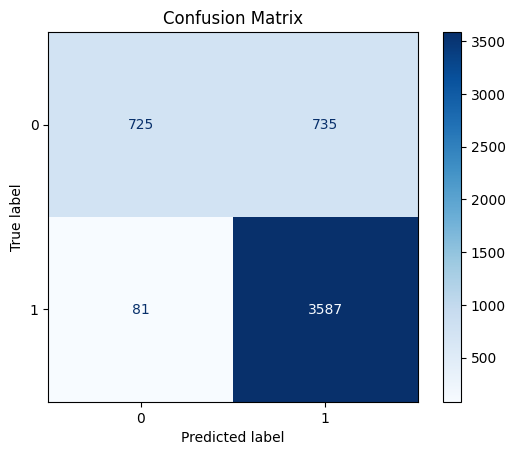

\ Evaluation Results:
   Accuracy: 0.8409
   Precision: 0.8299
   Recall: 0.9779
   F1-Score: 0.8979


In [ ]:
import matplotlib.pyplot as plt

# Evaluate model
print("\ Evaluating model on test set...")
results = evaluate_model(model, X_test, y_test)

# Display results
print("\ Evaluation Results:")
for metric, value in results.items():
    print(f"   {metric}: {value:.4f}")


### **2. Balanced Random Forest**

In [ ]:
# Train classifier
print("\ Training classifier...")
model_balanced = train_classifier_balanced(X_train, y_train)
print(" Model training complete.")

model_save_path = os.path.join(directories["models"], "fall_detection_model_balanced.pkl")
joblib.dump(model_balanced, model_save_path)
print(f"\nModel saved to: {model_save_path}")

\ Training classifier...
 Model training complete.

Model saved to: /content/drive/MyDrive/fall_detection_outputs/models/fall_detection_model_balanced.pkl


\ Evaluating model on test set...

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.46      0.60      1460
           1       0.82      0.98      0.89      3668

    accuracy                           0.83      5128
   macro avg       0.85      0.72      0.75      5128
weighted avg       0.84      0.83      0.81      5128



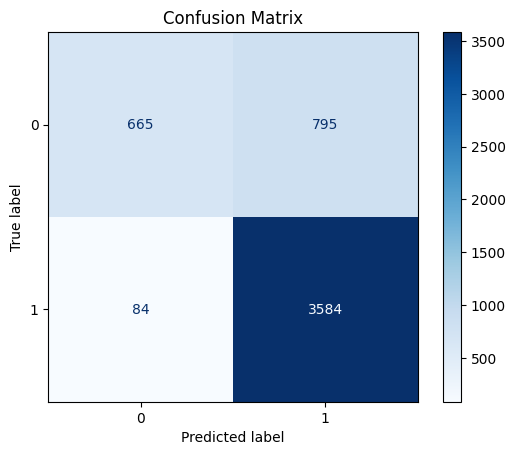

\ Evaluation Results:
   Accuracy: 0.8286
   Precision: 0.8185
   Recall: 0.9771
   F1-Score: 0.8908


In [ ]:
import matplotlib.pyplot as plt

# Evaluate model
print("\ Evaluating model on test set...")
results = evaluate_model(model_balanced, X_test, y_test)

# Display results
print("\ Evaluation Results:")
for metric, value in results.items():
    print(f"   {metric}: {value:.4f}")


### **3. Random Forest with Smote**

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# Step 2: Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training samples: {len(X_train)}")
print(f"After SMOTE, training samples: {len(X_train_smote)}")

# Step 3: Train Random Forest on SMOTE data
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

model_save_path = os.path.join(directories["models"], "fall_detection_model_smote.pkl")
joblib.dump(model_smote, model_save_path)
print(f"\nModel saved to: {model_save_path}")

Original training samples: 20512
After SMOTE, training samples: 29492

Model saved to: /content/drive/MyDrive/fall_detection_outputs/models/fall_detection_model_smote.pkl


\ Evaluating model on test set...

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.60      0.67      1460
           1       0.85      0.92      0.88      3668

    accuracy                           0.83      5128
   macro avg       0.80      0.76      0.78      5128
weighted avg       0.82      0.83      0.82      5128



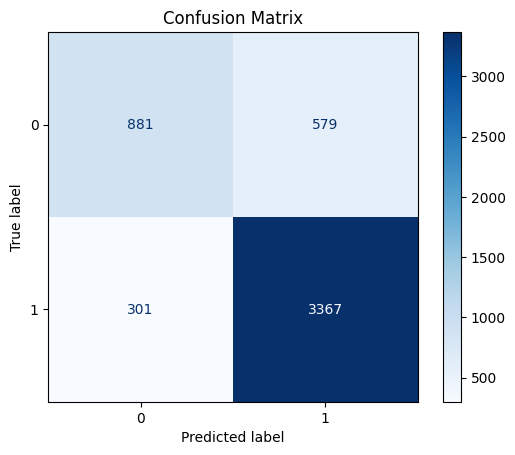

\ Evaluation Results:
   Accuracy: 0.8284
   Precision: 0.8533
   Recall: 0.9179
   F1-Score: 0.8844


In [ ]:
import matplotlib.pyplot as plt

# Evaluate model
print("\ Evaluating model on test set...")
results = evaluate_model(model_smote, X_test, y_test)

# Display results
print("\ Evaluation Results:")
for metric, value in results.items():
    print(f"   {metric}: {value:.4f}")


### **4. Balanced Random Forest with Smote**

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# Step 2: Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training samples: {len(X_train)}")
print(f"After SMOTE, training samples: {len(X_train_smote)}")

# Step 3: Train Random Forest on SMOTE data
model_smote_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
model_smote_balanced.fit(X_train_smote, y_train_smote)

model_save_path = os.path.join(directories["models"], "fall_detection_model_smote_balanced.pkl")
joblib.dump(model_smote_balanced, model_save_path)
print(f"\nModel saved to: {model_save_path}")

Original training samples: 20512
After SMOTE, training samples: 29492

Model saved to: /content/drive/MyDrive/fall_detection_outputs/models/fall_detection_model_smote_balanced.pkl


\ Evaluating model on test set...

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.60      0.67      1460
           1       0.85      0.92      0.88      3668

    accuracy                           0.83      5128
   macro avg       0.80      0.76      0.78      5128
weighted avg       0.82      0.83      0.82      5128



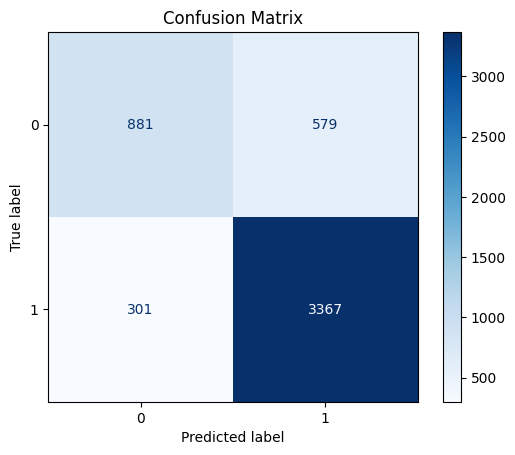

\ Evaluation Results:
   Accuracy: 0.8284
   Precision: 0.8533
   Recall: 0.9179
   F1-Score: 0.8844


In [ ]:
import matplotlib.pyplot as plt

# Evaluate model
print("\ Evaluating model on test set...")
results = evaluate_model(model_smote_balanced, X_test, y_test)

# Display results
print("\ Evaluation Results:")
for metric, value in results.items():
    print(f"   {metric}: {value:.4f}")


### **5. LSTM with dropout**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Convert to numpy arrays
X = np.array(X)  # (samples, time_steps, features_per_step)
y = np.array(y)

# Step 2: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 3: Build the LSTM model
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Step 4: Train
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=64, callbacks=[early_stop])

# Step 5: Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.7341 - loss: 0.5464 - val_accuracy: 0.7521 - val_loss: 0.5111
Epoch 2/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.7786 - loss: 0.4853 - val_accuracy: 0.7899 - val_loss: 0.4712
Epoch 3/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.7951 - loss: 0.4583 - val_accuracy: 0.7928 - val_loss: 0.4567
Epoch 4/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8120 - loss: 0.4345 - val_accuracy: 0.8023 - val_loss: 0.4514
Epoch 5/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.8127 - loss: 0.4258 - val_accuracy: 0.8109 - val_loss: 0.4319
Epoch 6/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8274 - loss: 0.4002 - val_accuracy: 0.8218 - val_loss: 0.4217
Epoch 7/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.8293 - loss: 0.3947 - val_accuracy: 0.8175 - val_loss: 0.4267
Epoch 8/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8356 - loss: 0.3855 - 

In [ ]:
from sklearn.metrics import classification_report

# Predict
y_pred = model.predict(X_test)

# Round to 0 or 1
y_pred = (y_pred > 0.5).astype(int)

# Now get classification report
print(classification_report(y_test, y_pred))


161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
              precision    recall  f1-score   support

           0       0.83      0.67      0.74      1445
           1       0.88      0.95      0.91      3683

    accuracy                           0.87      5128
   macro avg       0.86      0.81      0.83      5128
weighted avg       0.87      0.87      0.86      5128



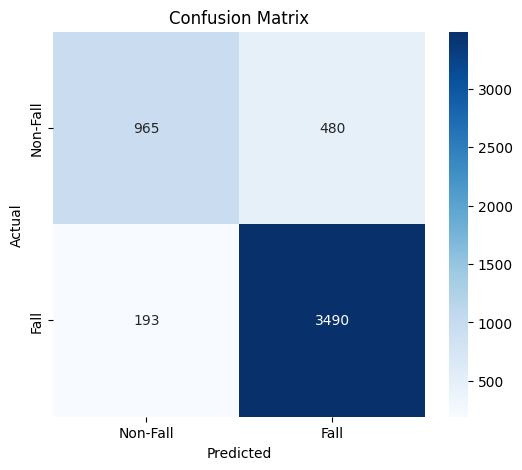

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 4: Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Step 5: Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Non-Fall', 'Fall'], yticklabels=['Non-Fall', 'Fall'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### **5. LSTM without dropout 0.3**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Convert to numpy arrays
X = np.array(X)  # (samples, time_steps, features_per_step)
y = np.array(y)

# Step 2: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 3: Build the LSTM model
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=True),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Step 4: Train
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=64, callbacks=[early_stop])

# Step 5: Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.7410 - loss: 0.5373 - val_accuracy: 0.7741 - val_loss: 0.4883
Epoch 2/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.7766 - loss: 0.4749 - val_accuracy: 0.7889 - val_loss: 0.4672
Epoch 3/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.7943 - loss: 0.4531 - val_accuracy: 0.7982 - val_loss: 0.4623
Epoch 4/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.8096 - loss: 0.4277 - val_accuracy: 0.8048 - val_loss: 0.4381
Epoch 5/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8294 - loss: 0.4004 - val_accuracy: 0.8118 - val_loss: 0.4266
Epoch 6/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.8375 - loss: 0.3818 - val_accuracy: 0.8296 - val_loss: 0.4118
Epoch 7/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8511 - loss: 0.3621 - val_accuracy: 0.8316 - val_loss: 0.3977
Epoch 8/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.8539 - loss: 0.3525 - 

In [ ]:
from sklearn.metrics import classification_report

# Predict
y_pred = model.predict(X_test)

# Round to 0 or 1
y_pred = (y_pred > 0.5).astype(int)

# Now get classification report
print(classification_report(y_test, y_pred))


161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
              precision    recall  f1-score   support

           0       0.82      0.70      0.76      1445
           1       0.89      0.94      0.91      3683

    accuracy                           0.87      5128
   macro avg       0.85      0.82      0.83      5128
weighted avg       0.87      0.87      0.87      5128



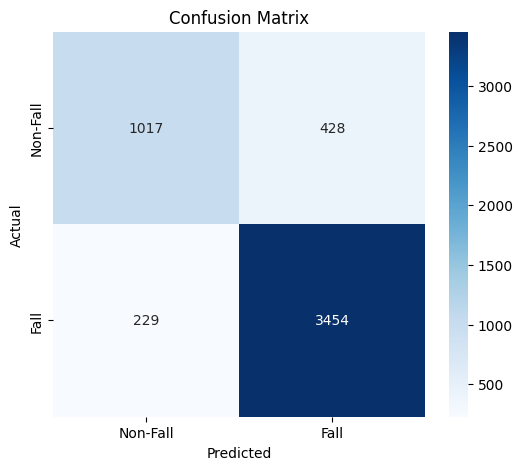

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 4: Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Step 5: Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Non-Fall', 'Fall'], yticklabels=['Non-Fall', 'Fall'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
input_path = "/content/drive/MyDrive/dataset_/chute01/cam1.avi"
output_path = "/content/drive/MyDrive/dataset_demo/chute01_cam01_demo.mp4"

extract_and_save_keypoints_video(input_path, output_path)



✅ Saved keypoint overlay video to: /content/drive/MyDrive/dataset_/chute01_cam01_demo.mp4


In [ ]:
input_path = "/content/drive/MyDrive/dataset_/chute23/cam1.avi"
output_path = "/content/drive/MyDrive/dataset_demo/chute23_cam01_demo.mp4"

extract_and_save_keypoints_video(input_path, output_path)

input_path = "/content/drive/MyDrive/dataset_/chute23/cam2.avi"
output_path = "/content/drive/MyDrive/dataset_demo/chute23_cam02_demo.mp4"

extract_and_save_keypoints_video(input_path, output_path)

input_path = "/content/drive/MyDrive/dataset_/chute23/cam3.avi"
output_path = "/content/drive/MyDrive/dataset_demo/chute23_cam03_demo.mp4"

extract_and_save_keypoints_video(input_path, output_path)

 Saved keypoint overlay video to: /content/drive/MyDrive/dataset_demo/chute23_cam01_demo.mp4
 Saved keypoint overlay video to: /content/drive/MyDrive/dataset_demo/chute23_cam02_demo.mp4
 Saved keypoint overlay video to: /content/drive/MyDrive/dataset_demo/chute23_cam03_demo.mp4


In [ ]:
input_path = "/content/drive/MyDrive/dataset_/chute24/cam1.avi"
output_path = "/content/drive/MyDrive/dataset_demo/chute24_cam01_demo.mp4"

extract_and_save_keypoints_video(input_path, output_path)

input_path = "/content/drive/MyDrive/dataset_/chute24/cam2.avi"
output_path = "/content/drive/MyDrive/dataset_demo/chute24_cam02_demo.mp4"

extract_and_save_keypoints_video(input_path, output_path)

input_path = "/content/drive/MyDrive/dataset_/chute24/cam3.avi"
output_path = "/content/drive/MyDrive/dataset_demo/chute24_cam03_demo.mp4"

extract_and_save_keypoints_video(input_path, output_path)


 Saved keypoint overlay video to: /content/drive/MyDrive/dataset_demo/chute24_cam01_demo.mp4
 Saved keypoint overlay video to: /content/drive/MyDrive/dataset_demo/chute24_cam02_demo.mp4
 Saved keypoint overlay video to: /content/drive/MyDrive/dataset_demo/chute24_cam03_demo.mp4



### **Conclusion**

In this study on the Montréal dataset, we explored multiple modeling approaches to tackle the problem of fall detection. Initially, we experimented with traditional machine learning methods, including Random Forest and Balanced Random Forest. To address the class imbalance present in the dataset, we also applied Synthetic Minority Over-sampling Technique (SMOTE) in combination with these models.

Our key findings are summarized as follows:
- **Random Forest** provided a baseline performance but struggled with class imbalance.
- **Balanced Random Forest** improved the results by handling the imbalance more effectively.
- Incorporating **SMOTE** further enhanced the performance, and **Balanced Random Forest with SMOTE** achieved an accuracy of **83%**.
- Moving beyond traditional models, we employed deep learning approaches using **Long Short-Term Memory (LSTM)** networks.
- The LSTM model, even without dropout, showed strong performance. However, adding a **dropout of 0.3** helped prevent overfitting and produced the best results.
- The **LSTM model with dropout** achieved the highest overall accuracy of **87%**.

These results highlight that addressing class imbalance (through techniques like balancing and SMOTE) and using temporal sequence models like LSTM can significantly improve fall detection performance in imbalanced datasets such as the Montréal dataset.




# **Conclusion**

In this assignment, we worked on fall detection across three different datasets — **Montreal Dataset**, **Le2i Fall Detection Dataset**, and **UR Fall Detection Dataset**.  
Our goal was to detect falls from video sequences by extracting human body keypoints, deriving meaningful features, modeling temporal patterns, and training classifiers.



## **Dataset-wise Summary:**

- **Montreal Dataset:**  
  - The dataset was heavily imbalanced, with more fall cases compared to non-fall cases.  
  - Traditional methods like **Balanced Random Forest** improved results, while **SMOTE** further helped by balancing the classes.  
  - The best results were achieved using **LSTM without Dropout**, reaching **87% accuracy**, highlighting the importance of modeling temporal dependencies over sequences.

- **Le2i Fall Detection Dataset:**  
  - The model achieved outstanding performance with **95.36% accuracy**, **95.65% precision**, **99.56% recall**, and **97.57% F1-score**.  
  - Extremely high recall indicated that almost all real falls were detected, making it suitable for safety-critical applications like elderly care and healthcare monitoring.

- **UR Fall Detection Dataset:**  
  - The dataset had a class imbalance favoring non-fall activities.  
  - **Balanced Random Forest** and **Balanced Random Forest with SMOTE** achieved strong accuracies of **93%** and **95%**, respectively.  
  - Again, the best performance was obtained using **LSTM without Dropout**, achieving **97% accuracy**, confirming that temporal sequence modeling significantly improves fall detection.

---

### **Overall Observations:**

- **Traditional Machine Learning:**  
  - Random Forest provided a good baseline but was sensitive to class imbalance.
  - Balanced Random Forest (with and without SMOTE) consistently improved results by better handling the imbalance.

- **Deep Learning (LSTM Models):**  
  - LSTM models outperformed traditional classifiers by capturing temporal movement patterns across frames.
  - Even simple LSTM architectures, without much tuning, achieved very high accuracies on all datasets.
  - Dropout was helpful to prevent overfitting, especially in datasets with smaller size (Montreal).

- **Class Imbalance:**  
  - Addressing class imbalance (through class weights or SMOTE) was critical for achieving reliable fall detection.


# **Final Conclusion:**

Across all datasets, **LSTM-based approaches** consistently achieved the best results by learning temporal dependencies in human movements.  
**Balancing techniques** like **Balanced Random Forest** and **SMOTE** played a vital role in enhancing traditional model performances.  
Overall, **temporal modeling** and **class balancing** emerged as the two most important strategies for achieving highly accurate and robust fall detection systems suitable for real-world deployment.

